# Cross-Version Benchmark Leaderboards

This notebook builds leaderboards from benchmark outputs in `benchmarking/benchmarks/*/results/baseline` and `v10+`.

When present, `baseline` is the CLIP-only ablation (no caption generation, keyword search, or hybrid search).

It includes:
- Primary leaderboard (`MRR`, `Success@25`)
- Primary + Diversity leaderboard (adds `Diversity@25`)

`Success@25` is computed from the `hit` column mean.


A separate **Primary leaderboard (with ablation studies)** section includes `ablation_*` runs alongside baseline and `v10+`.


In [1]:
import sys
from pathlib import Path
from IPython.display import display

# Repo root from benchmarking/benchmarks/<BENCHMARK>/results
_repo_root = Path.cwd().parents[3]
sys.path.insert(0, str(_repo_root))

base_path = (_repo_root / "benchmarking" / "benchmarks").resolve()

from benchmarking.helpers.plot import (
    render_single_benchmark_leaderboard,
    DEFAULT_PRIMARY_WEIGHTS,
    DEFAULT_PRIMARY_PLUS_DIVERSITY_WEIGHTS,
)

In [2]:
# Configuration
# This notebook ranks only the benchmark folder it lives in.
# Expected cwd when running this notebook: benchmarking/benchmarks/<BENCHMARK>/results
current_benchmark = Path.cwd().parents[0].name if Path.cwd().name == "results" else Path.cwd().name
min_version = 10

# Default metric weights are equal, but can be customized.
primary_metric_weights = dict(DEFAULT_PRIMARY_WEIGHTS)
primary_plus_diversity_metric_weights = dict(DEFAULT_PRIMARY_PLUS_DIVERSITY_WEIGHTS)

print("Base path:", base_path)
print("Benchmark selected:", current_benchmark)
print("Primary weights:", primary_metric_weights)
print("Primary + Diversity weights:", primary_plus_diversity_metric_weights)

Base path: /home/runner/work/sage-nrp-image-search/sage-nrp-image-search/benchmarking/benchmarks
Benchmark selected: Firebench
Primary weights: {'MRR': 0.5, 'Success@25': 0.5}
Primary + Diversity weights: {'MRR': 0.3333333333333333, 'Success@25': 0.3333333333333333, 'Diversity@25': 0.3333333333333333}


## Primary Leaderboard

Ranking uses weighted composite of:
- `MRR`
- `Success@25`


Firebench (Primary):


,benchmark,system_version,query_count,MRR,Success@25,Precision@25,NDCG@25,Recall@25,Diversity@25,composite_score,rank_within_benchmark
0,Firebench,v10,100,0.780303,0.56,0.0592,0.803481,0.108901,0.244647,0.670152,1
1,Firebench,baseline,100,0.662626,0.64,0.0636,0.816923,0.096295,0.122002,0.651313,2
2,Firebench,v11,100,0.615921,0.61,0.0544,0.761870,0.099311,0.255128,0.612961,3
3,Firebench,v12,100,0.365920,0.63,0.0608,0.667371,0.111765,0.256171,0.497960,4


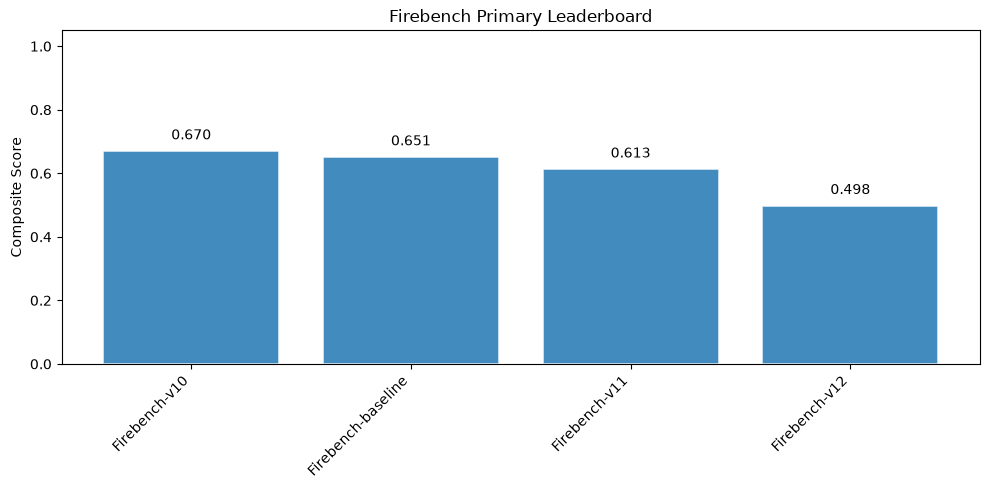

In [3]:
primary_df = render_single_benchmark_leaderboard(
    base_path=base_path,
    benchmark=current_benchmark,
    min_version=min_version,
    mode="primary",
    metric_weights=primary_metric_weights,
    display_fn=display,
)

## Primary + Diversity Leaderboard

Adds `Diversity@25` to the weighted score.


Firebench (Primary + Diversity):


,benchmark,system_version,query_count,MRR,Success@25,Precision@25,NDCG@25,Recall@25,Diversity@25,composite_score,rank_within_benchmark
0,Firebench,v10,100,0.780303,0.56,0.0592,0.803481,0.108901,0.244647,0.528317,1
1,Firebench,v11,100,0.615921,0.61,0.0544,0.761870,0.099311,0.255128,0.493683,2
2,Firebench,baseline,100,0.662626,0.64,0.0636,0.816923,0.096295,0.122002,0.474876,3
3,Firebench,v12,100,0.365920,0.63,0.0608,0.667371,0.111765,0.256171,0.417364,4


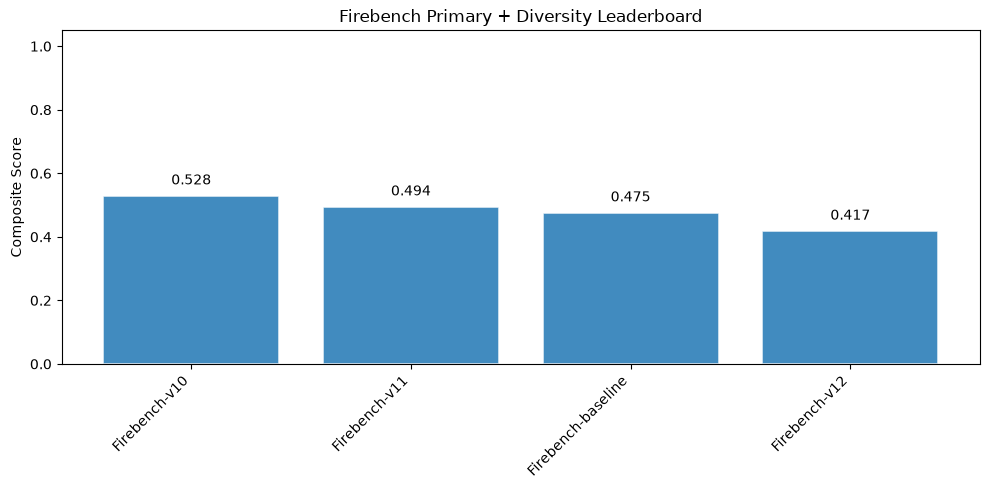

In [4]:
primary_plus_diversity_df = render_single_benchmark_leaderboard(
    base_path=base_path,
    benchmark=current_benchmark,
    min_version=min_version,
    mode="primary_plus_diversity",
    metric_weights=primary_plus_diversity_metric_weights,
    display_fn=display,
)

## Primary Leaderboard (with Ablation Studies)

Same weighted composite as the primary leaderboard (`MRR`, `Success@25`), but also includes `ablation_*` result folders when present.



Firebench (Primary (with Ablation Studies)):


,benchmark,system_version,query_count,MRR,Success@25,Precision@25,NDCG@25,Recall@25,Diversity@25,composite_score,rank_within_benchmark
0,Firebench,ablation_img_only,100,0.733111,0.68,0.0732,0.805750,0.127553,0.145383,0.706556,1
1,Firebench,v10,100,0.780303,0.56,0.0592,0.803481,0.108901,0.244647,0.670152,2
2,Firebench,baseline,100,0.662626,0.64,0.0636,0.816923,0.096295,0.122002,0.651313,3
3,Firebench,v11,100,0.615921,0.61,0.0544,0.761870,0.099311,0.255128,0.612961,4
4,Firebench,ablation_cap_only,100,0.667148,0.55,0.0508,0.774482,0.096595,0.369309,0.608574,5
5,Firebench,v12,100,0.365920,0.63,0.0608,0.667371,0.111765,0.256171,0.497960,6


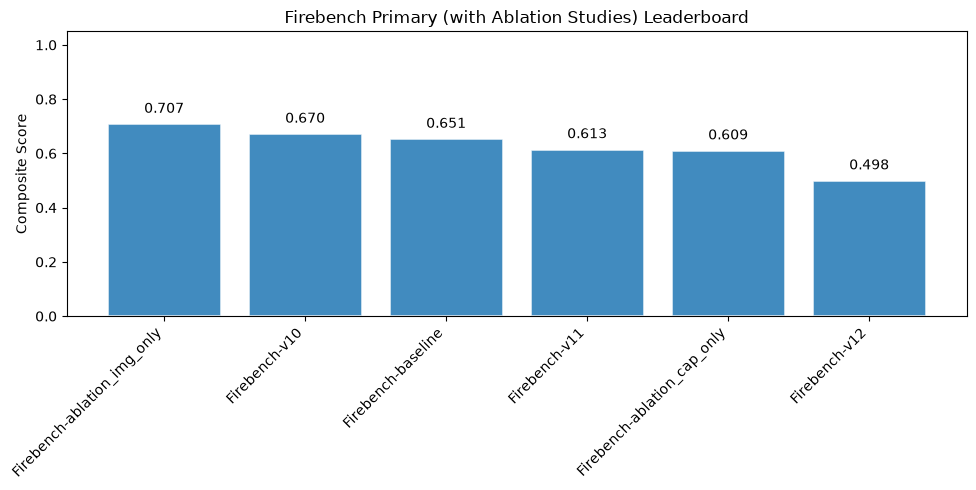

In [5]:
primary_ablation_df = render_single_benchmark_leaderboard(
    base_path=base_path,
    benchmark=current_benchmark,
    min_version=min_version,
    include_ablations=True,
    mode="primary",
    metric_weights=primary_metric_weights,
    display_fn=display,
)